<a href="https://colab.research.google.com/github/faiq191/244107020214-machine-learning/blob/main/JS04/JS04_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. SETUP & DATA LOADING

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

df = pd.read_csv('insurance.csv')

print("Dataset Overview:")
print(df.info())
print("\nFirst 5 rows:")
print(df.head())

Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None

First 5 rows:
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


2. EXPLORATORY DATA ANALYSIS (VISUALIZATIONS)

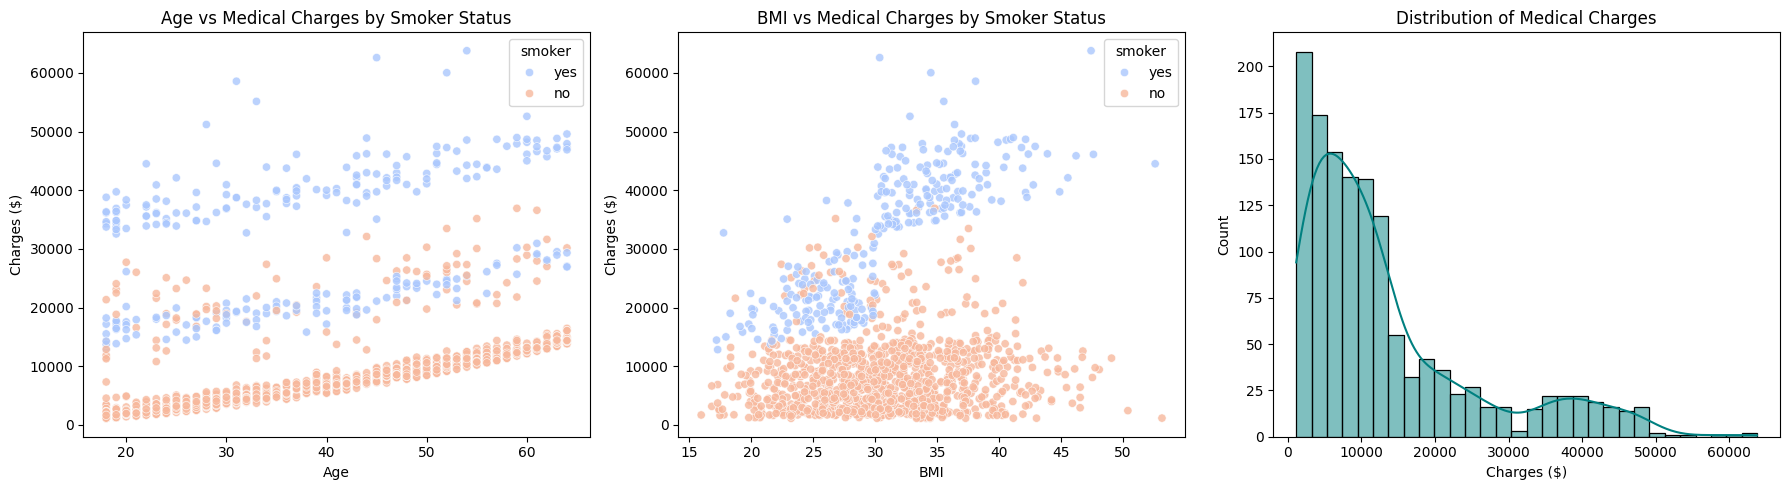

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(ax=axes[0], data=df, x='age', y='charges', hue='smoker', palette='coolwarm', alpha=0.8)
axes[0].set_title('Age vs Medical Charges by Smoker Status')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Charges ($)')

sns.scatterplot(ax=axes[1], data=df, x='bmi', y='charges', hue='smoker', palette='coolwarm', alpha=0.8)
axes[1].set_title('BMI vs Medical Charges by Smoker Status')
axes[1].set_xlabel('BMI')
axes[1].set_ylabel('Charges ($)')

sns.histplot(ax=axes[2], data=df, x='charges', kde=True, color='teal')
axes[2].set_title('Distribution of Medical Charges')
axes[2].set_xlabel('Charges ($)')

plt.tight_layout()
plt.show()

3. DATA SPLITTING & PREPROCESSING

In [ ]:
X = df.drop(columns=['charges'])
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

numeric_cols = ['age', 'bmi', 'children']
categorical_cols = ['sex', 'smoker', 'region']

preprocessor_lr = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ]
)

preprocessor_svr = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ]
)

X_train_lr = preprocessor_lr.fit_transform(X_train)
X_test_lr = preprocessor_lr.transform(X_test)

X_train_svr = preprocessor_svr.fit_transform(X_train)
X_test_svr = preprocessor_svr.transform(X_test)

scaler_y = StandardScaler()
y_train_svr = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()

print("Ukuran Data:")
print(f"- Data latih (X_train): {X_train.shape[0]} baris, {X_train.shape[1]} kolom awal")
print(f"- Data uji   (X_test) : {X_test.shape[0]} baris, {X_test.shape[1]} kolom awal")
print(f"- Fitur setelah One-Hot Encoding: {X_train_svr.shape[1]} kolom")

print("\nContoh 1 baris fitur setelah di-scaling (SVR):")
print(np.round(X_train_svr[0], 4))

print("\nContoh nama fitur baru:")
feature_names = preprocessor_svr.get_feature_names_out()
print(list(feature_names))

Ukuran Data:
- Data latih (X_train): 1070 baris, 6 kolom awal
- Data uji   (X_test) : 268 baris, 6 kolom awal
- Fitur setelah One-Hot Encoding: 8 kolom

Contoh 1 baris fitur setelah di-scaling (SVR):
[ 0.4722 -1.7565  0.7343  0.      0.      1.      0.      0.    ]

Contoh nama fitur baru:
['num__age', 'num__bmi', 'num__children', 'cat__sex_male', 'cat__smoker_yes', 'cat__region_northwest', 'cat__region_southeast', 'cat__region_southwest']


4. MULTIPLE LINEAR REGRESSION

In [ ]:
lr = LinearRegression()
lr.fit(X_train_lr, y_train)

y_pred_lr = lr.predict(X_test_lr)

lr_r2 = r2_score(y_test, y_pred_lr)
lr_mse = mean_squared_error(y_test, y_pred_lr)
lr_mae = mean_absolute_error(y_test, y_pred_lr)

5. SUPPORT VECTOR REGRESSION (SVR) + TUNING

In [16]:
param_grid = {
    'C': [10, 50, 100, 200],
    'gamma': ['scale', 'auto', 0.1, 0.01],
    'epsilon': [0.05, 0.1, 0.2]
}

grid_svr = GridSearchCV(
    estimator=SVR(kernel='rbf'),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
grid_svr.fit(X_train_svr, y_train_svr)

best_svr = grid_svr.best_estimator_
y_pred_svr_scaled = best_svr.predict(X_test_svr)
y_pred_svr = scaler_y.inverse_transform(y_pred_svr_scaled.reshape(-1, 1)).ravel()

svr_r2 = r2_score(y_test, y_pred_svr)
svr_mse = mean_squared_error(y_test, y_pred_svr)
svr_mae = mean_absolute_error(y_test, y_pred_svr)

print("Best SVR Parameters:", grid_svr.best_params_)

Best SVR Parameters: {'C': 10, 'epsilon': 0.1, 'gamma': 0.1}


6. MODEL COMPARISON & RESIDUAL PLOTS


--- Model Evaluation Summary ---
                   Metric Linear Regression Tuned SVR (RBF)
        R-squared ($R^2$)            0.7836          0.8691
 Mean Squared Error (MSE)     33,596,915.85   20,319,848.31
Mean Absolute Error (MAE)         $4,181.19       $2,386.83
                     RMSE         $5,796.28       $4,507.75


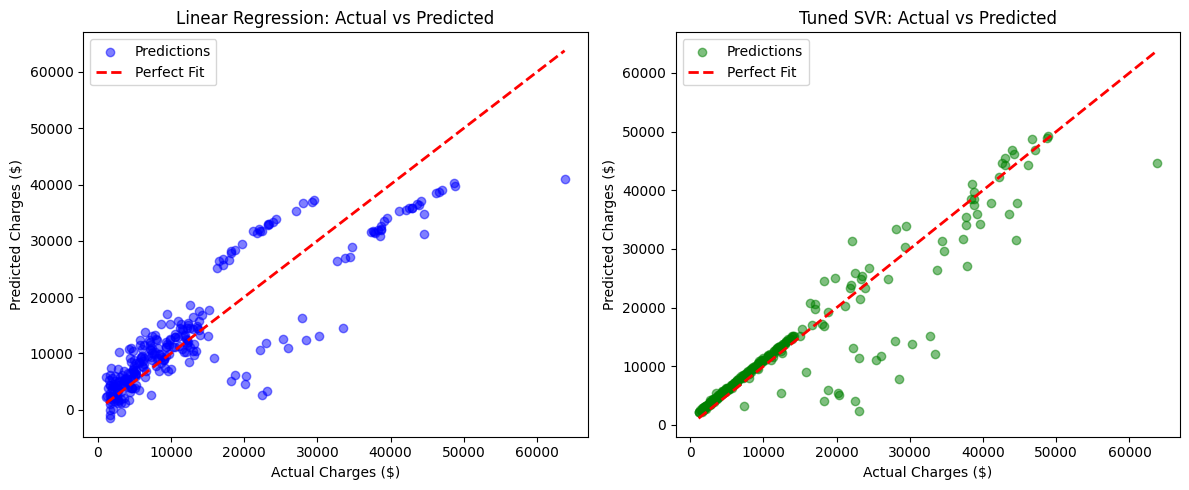

In [17]:
results_df = pd.DataFrame({
    'Metric': ['R-squared ($R^2$)', 'Mean Squared Error (MSE)', 'Mean Absolute Error (MAE)', 'RMSE'],
    'Linear Regression': [f"{lr_r2:.4f}", f"{lr_mse:,.2f}", f"${lr_mae:,.2f}", f"${np.sqrt(lr_mse):,.2f}"],
    'Tuned SVR (RBF)': [f"{svr_r2:.4f}", f"{svr_mse:,.2f}", f"${svr_mae:,.2f}", f"${np.sqrt(svr_mse):,.2f}"]
})
print("\n--- Model Evaluation Summary ---")
print(results_df.to_string(index=False))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_lr, color='blue', alpha=0.5, label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit')
plt.title('Linear Regression: Actual vs Predicted')
plt.xlabel('Actual Charges ($)')
plt.ylabel('Predicted Charges ($)')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_svr, color='green', alpha=0.5, label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit')
plt.title('Tuned SVR: Actual vs Predicted')
plt.xlabel('Actual Charges ($)')
plt.ylabel('Predicted Charges ($)')
plt.legend()

plt.tight_layout()
plt.show()